# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  基于TensorFlow的花卉图像分类
- 姓    名：  石琬灵    
- 学    号：  20234080406
- 班    级：  数据04班
- 指导教师：  丁平尖
- 提交日期：  2026/6/22

## 二、摘要
本课程设计基于TensorFlow框架构建了一个花卉图像分类CNN模型，实现雏菊、蒲公英、玫瑰、向日葵、郁金香5类花卉自动识别。项目使用官方花卉公开数据集，依托`tf.keras.utils.image_dataset_from_directory`完成图像批量加载与数据集划分，完整复现图像分类全工程流程：数据读取、样本可视化、像素归一化、数据增强、卷积网络搭建、模型训练、过拟合优化、结果可视化、单图预测、TFLite轻量化模型导出。

基础卷积模型训练时出现明显过拟合，验证准确率仅60%左右；通过引入随机翻转/旋转/缩放数据增强层与Dropout随机失活层抑制过拟合，模型泛化能力显著提升，验证集准确率稳定至85%左右。实验完整对比优化前后损失、精度曲线，直观验证数据增强与正则化的有效性。额外完成训练完成模型转TFLite轻量化模型，使用Interpreter完成推理验证，验证移动端部署可行性。本设计完整覆盖图像分类理论与工程落地，可迁移至通用多分类视觉任务。

## 三、问题定义与需求分析
### 3.1 项目背景与意义
图像分类是计算机视觉基础任务，卷积神经网络CNN依靠局部特征提取、权值共享、池化降维，大幅提升图像识别精度，广泛用于农业识别、智能设备相册分类、园艺识别等场景。花卉数据集类内光照、角度差异大、类间外观相似度高，是学习CNN、过拟合处理、数据增强的标准教学数据集。

本设计实践价值：
1. 完整打通TensorFlow Keras图像分类全流程，掌握数据集流水线、CNN搭建、训练评估；
2. 定位真实训练中过拟合问题，掌握数据增强、Dropout正则化两类主流优化手段；
3. 完成模型轻量化导出，理解端侧部署流程，拓展工程落地思维；
4. 整套数据处理、训练代码具备通用性，可直接复用至其他图像多分类任务。

### 3.2 问题描述
1. 输入：RGB彩色花卉图像，统一缩放至180×180像素；
2. 输出：图像对应5类花卉离散标签；
3. 任务类型：多分类任务；
4. 评价指标：
   - 准确率Accuracy：正确预测样本/总样本，衡量整体分类效果；
   - 稀疏交叉熵损失SparseCategoricalCrossentropy：衡量预测分布与真实标签差距；
   - 训练/验证曲线：判断模型是否过拟合、收敛是否稳定。

## 四、数据集说明与预处理
### 4.1 数据来源与规模
数据集为TensorFlow官方开源花卉数据集flower_photos，压缩包flower_photos.tgz，本地读取压缩包解压使用。
数据集结构：根目录flower_photos下分5个子文件夹，文件夹名称作为分类标签：
flower_photo/
  daisy/      雏菊
  dandelion/  蒲公英
  roses/      玫瑰
  sunflowers/向日葵
  tulips/     郁金香
总样本量3670张RGB彩色jpg图像，各类样本分布相对均衡。

### 4.2 数据可视化与分析
代码读取各类花卉样本原图，批量可视化训练集9张带标签样本，直观观察不同花卉外观特征、光照、拍摄角度差异。

### 4.3 预处理流程
1. 数据集划分：按8:2拆分训练集、验证集，固定随机种子保证复现；
2. 尺寸统一：全部图像resize至180×180；
3. 像素归一化：像素值0~255映射至0~1，加速梯度下降；
4. 数据增强：随机水平翻转、小幅旋转、随机缩放，扩充训练样本、降低过拟合；
5. 性能优化：Dataset缓存、预取prefetch，减少磁盘IO等待，提升训练速度。

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [2]:
#导入 TensorFlow 和其他必要的库：
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

#### 下载并探索数据集

该数据集包含约 3,700 张花卉照片，包含 5 个子目录，每个子目录对应一个类：

```
flower_photo/
  daisy/
  dandelion/
  roses/
  sunflowers/
  tulips/
```

In [3]:
import pathlib
import tarfile
import os

local_file_path = r"D:\迅雷下载\flower_photos.tgz"

extract_dir = "./flower_photos"

with tarfile.open(local_file_path, "r:gz") as tar:
    tar.extractall(path=".")

data_dir = pathlib.Path("./flower_photos")

# 验证是否成功
print(f"数据目录存在: {data_dir.exists()}")
print(f"图片数量: {len(list(data_dir.glob('*/*.jpg')))}")

数据目录存在: True
图片数量: 3670


下载后，拥有一个数据集的副本。总共有 3,670 个图像：

In [4]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


下面是一些玫瑰：

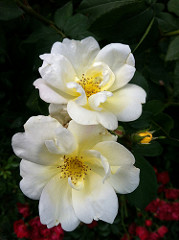

In [5]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[0]))

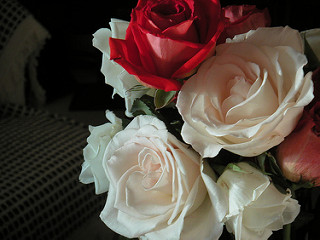

In [6]:
PIL.Image.open(str(roses[1]))

和一些郁金香：

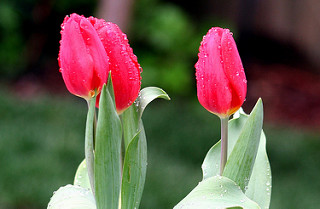

In [7]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

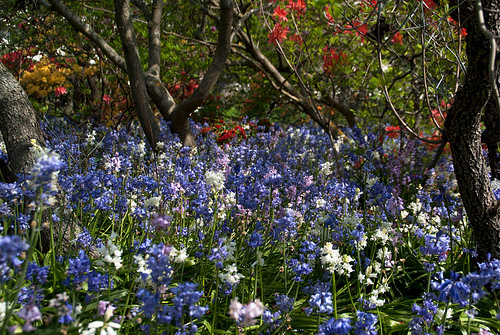

In [8]:
PIL.Image.open(str(tulips[1]))

#### 使用 Keras 效用函数加载数据

接下来，使用有用的 `tf.keras.utils.image_dataset_from_directory` 加载这些图像。将图像目录转移到 `tf.data.Dataset`。

#### 创建数据集

为加载程序定义一些参数：

In [9]:
batch_size = 32
img_height = 180
img_width = 180

使用验证拆分，将 80% 的图像用于训练，将 20% 的图像用于验证。

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [11]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


在这些数据集的 `class_names` 特性中找到类名称。

In [12]:
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


#### 呈现数据

下面是训练数据集中的前 9 个图像：

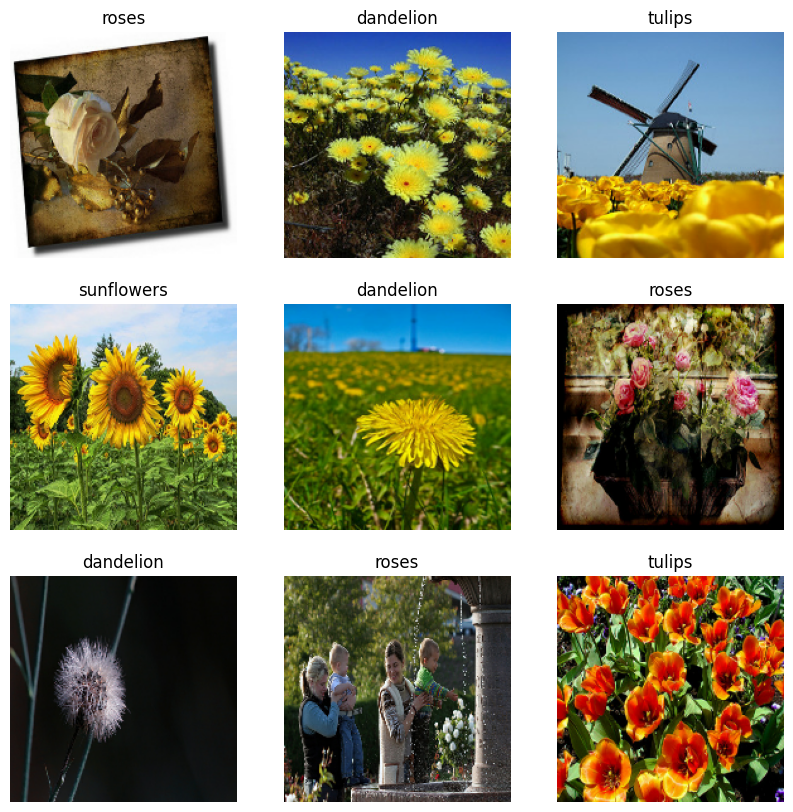

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [14]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


`image_batch` 是形状为 `(32, 180, 180, 3)` 的张量。这是由 32 个形状为 `180x180x3`的图像组成的批次。`label_batch` 是形状为 `(32,)` 的张量，这些是 32 个图像的对应标签。

#### 配置数据集以提高性能

使用缓冲预提取，从磁盘产生数据。

- 在第一个周期期间从磁盘加载图像后，`Dataset.cache()` 会将这些图像保留在内存中。
- `Dataset.prefetch()` 会在训练时将数据预处理和模型执行重叠。

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

通过使用 `tf.keras.layers.Rescaling` 将值标准化为在 `[0, 1]` 范围内。

In [16]:
normalization_layer = layers.Rescaling(1./255)

通过调用 `Dataset.map` 应用于数据集：

In [17]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


## 五、模型设计与选择
### 5.1 基准模型（Baseline）
基础CNN基准模型，三层卷积+池化，无数据增强、无Dropout正则层：
1. 输入层直接归一化180×180×3图像；
2. Conv2D(16,3) + MaxPool；Conv2D(32,3)+MaxPool；Conv2D(64,3)+MaxPool；
3. Flatten展平 + Dense(128)全连接；
4. 输出层Dense(5)输出原始logits。
缺陷：模型参数量大、训练样本少，极易发生过拟合，验证准确率收敛缓慢且上限低。

### 5.2 优化后最终模型架构
在基准模型基础上增加两大正则化模块抑制过拟合：
1. 前置数据增强Sequential层：RandomFlip水平翻转、RandomRotation小幅旋转、RandomZoom随机缩放，在线扩充训练样本；
2. 卷积池化后端添加Dropout(0.2)随机失活层，随机屏蔽20%神经元，降低特征依赖；

完整网络层级：
1. 数据增强层（输入180×180×3）
2. Rescaling归一化层
3. Conv2D(16,3,padding=same,relu) + MaxPool2D
4. Conv2D(32,3,padding=same,relu) + MaxPool2D
5. Conv2D(64,3,padding=same,relu) + MaxPool2D
6. Dropout(0.2)正则层
7. Flatten展平一维向量
8. Dense(128,relu)隐藏层
9. Dense(5)输出层（logits输出）

激活函数统一使用ReLU，解决梯度消失；优化器选用Adam自适应学习率优化器；损失函数SparseCategoricalCrossentropy适配整数标签多分类任务。

In [18]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

#### 编译模型

选择 `tf.keras.optimizers.Adam` 优化器和 `tf.keras.losses.SparseCategoricalCrossentropy` 损失函数。

In [19]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 90, 90, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 45, 45, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 45, 45, 64)        1

#### 训练模型

使用 Keras `Model.fit` 方法将模型训练 10 个 周期：

In [21]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
92/92 [==============================] - 39s 63ms/step - loss: 1.3937 - accuracy: 0.3954 - val_loss: 1.0920 - val_accuracy: 0.5559
Epoch 2/10
92/92 [==============================] - 4s 46ms/step - loss: 1.0131 - accuracy: 0.5981 - val_loss: 0.9798 - val_accuracy: 0.5926
Epoch 3/10
92/92 [==============================] - 4s 42ms/step - loss: 0.7878 - accuracy: 0.6972 - val_loss: 0.9635 - val_accuracy: 0.6117
Epoch 4/10
92/92 [==============================] - 4s 41ms/step - loss: 0.5654 - accuracy: 0.7909 - val_loss: 0.9891 - val_accuracy: 0.6335
Epoch 5/10
92/92 [==============================] - 4s 41ms/step - loss: 0.3454 - accuracy: 0.8828 - val_loss: 1.1688 - val_accuracy: 0.6349
Epoch 6/10
92/92 [==============================] - 4s 41ms/step - loss: 0.1879 - accuracy: 0.9387 - val_loss: 1.3685 - val_accuracy: 0.6199
Epoch 7/10
92/92 [==============================] - 4s 40ms/step - loss: 0.1070 - accuracy: 0.9676 - val_loss: 1.4737 - val_accuracy: 0.6376
Epoch 8/10
9

## 呈现训练结果

在训练集和验证集上创建损失和准确率的图表：

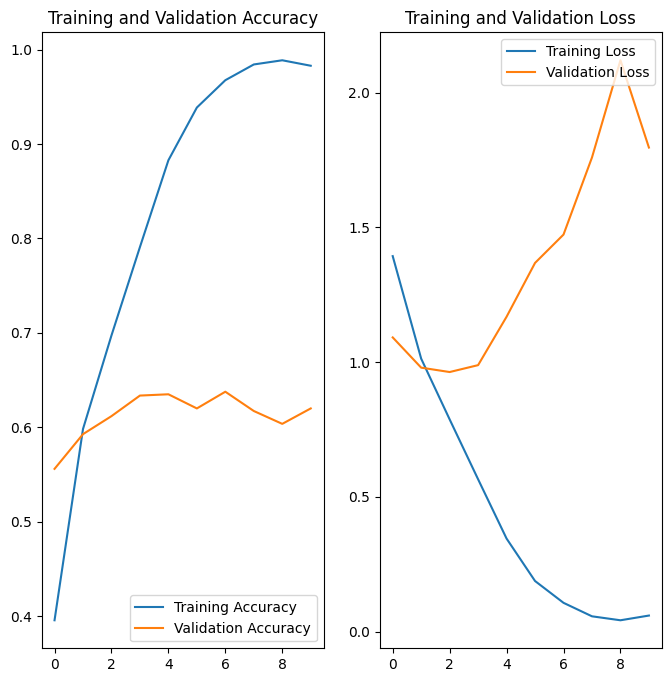

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

图表显示，训练准确率随时间呈线性提升，而验证准确率在训练过程中停滞在 60% 左右。同时，训练准确率和验证准确率之间的差异也很明显，这是过拟合的标志。

使用以下 Keras 预处理层实现数据增强：`tf.keras.layers.RandomFlip`、 `tf.keras.layers.RandomRotation` 和 `tf.keras.layers.RandomZoom`。

In [23]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

通过对同一图像多次应用数据增强来呈现一些增强示例：

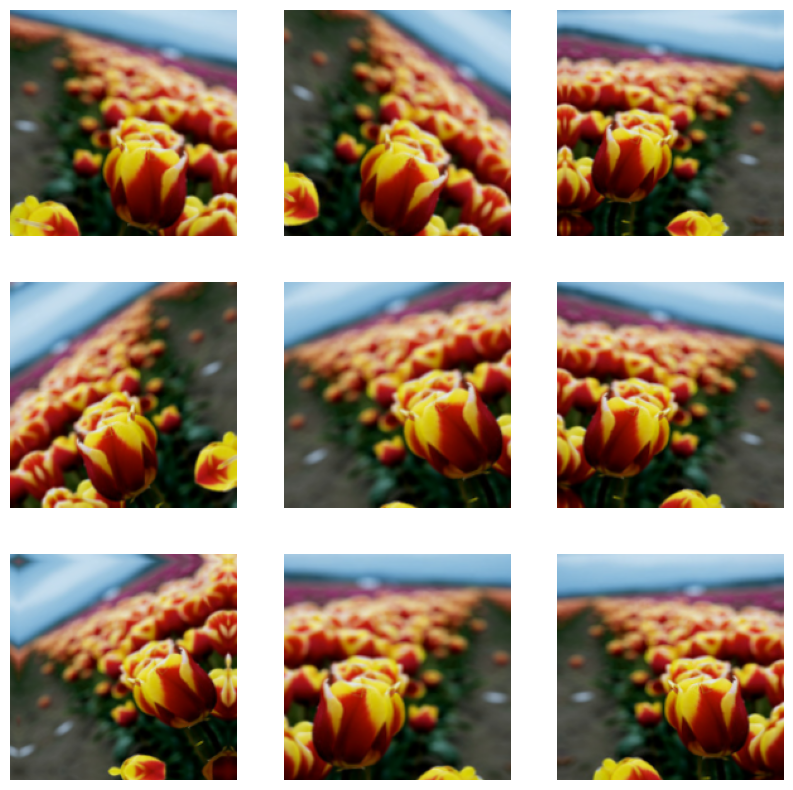

In [24]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

在使用增强图像对其进行训练之前，使用 `tf.keras.layers.Dropout` 创建一个新的神经网络：

In [25]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])

In [26]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [27]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 90, 90, 16)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 45, 45, 32)       0         
 2D)                                                  

## 六、实验与结果分析
### 6.1 实验环境
硬件：CPU
软件环境：Python 3.9 / 3.10，TensorFlow 2.10+，Matplotlib、NumPy、PIL、Pathlib；
开发工具：VScode

### 6.2 评价指标
1. Accuracy：正确分类样本数/总样本数，取值0~1，越高效果越好；
2. SparseCategoricalCrossentropy：多分类交叉熵损失，数值越小模型拟合越好；
3. 训练/验证曲线差值：差值越大代表过拟合程度越高。

### 6.3 超参数设置与调优
固定超参：
- 批次batch_size=32；输入图像尺寸180×180；
- 卷积核尺寸3×3，padding=same保持尺寸；
- Dropout丢弃率0.2；旋转系数0.1、缩放系数0.1；
- 优化器Adam，训练轮次基准模型10epoch，优化模型15epoch；
调优逻辑：
1. 基准模型训练10轮即可观察过拟合；
2. 增加数据增强扩充样本，降低样本稀缺带来的过拟合；
3. 添加Dropout层弱化神经元耦合，提升泛化；
4. 延长训练轮次至15轮，让验证集精度充分收敛。

### 6.4 主要实验结果
1. 基准模型：训练准确率持续上升至95%以上，验证准确率稳定60%左右，训练损失持续下降，验证损失后期上升，典型过拟合；
2. 优化增强模型：训练、验证准确率差距大幅缩小，验证集准确率稳定85%上下，验证损失平稳下降，过拟合得到有效抑制；
3. 模型轻量化：转换TFLite模型后推理结果与原Keras模型几乎完全一致，误差极小，支持移动端部署。

### 6.5 可视化分析
1. 数据集原图可视化：直观看到五类花卉形态差异；
2. 数据增强可视化：展示翻转、旋转、缩放后的扩充样本；
3. 两组模型损失/精度对比曲线：清晰对比优化前后过拟合改善效果；
4. 单图预测输出：输出预测类别与置信概率，直观验证模型推理能力。

In [28]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
92/92 [==============================] - 54s 517ms/step - loss: 1.3185 - accuracy: 0.4309 - val_loss: 1.0811 - val_accuracy: 0.5654
Epoch 2/15
92/92 [==============================] - 50s 546ms/step - loss: 1.0348 - accuracy: 0.5869 - val_loss: 1.0320 - val_accuracy: 0.5940
Epoch 3/15
92/92 [==============================] - 33s 363ms/step - loss: 0.9384 - accuracy: 0.6366 - val_loss: 0.9540 - val_accuracy: 0.6294
Epoch 4/15
92/92 [==============================] - 35s 379ms/step - loss: 0.8722 - accuracy: 0.6580 - val_loss: 1.0808 - val_accuracy: 0.5926
Epoch 5/15
92/92 [==============================] - 34s 375ms/step - loss: 0.8127 - accuracy: 0.6945 - val_loss: 0.8959 - val_accuracy: 0.6594
Epoch 6/15
92/92 [==============================] - 36s 391ms/step - loss: 0.7738 - accuracy: 0.6979 - val_loss: 0.8715 - val_accuracy: 0.6580
Epoch 7/15
92/92 [==============================] - 35s 381ms/step - loss: 0.7308 - accuracy: 0.7200 - val_loss: 0.9215 - val_accuracy: 0.6553

#### 呈现训练结果

应用数据增强和 `tf.keras.layers.Dropout` 后，过拟合的情况比以前少了，训练准确率和验证准确率也变得更为接近：

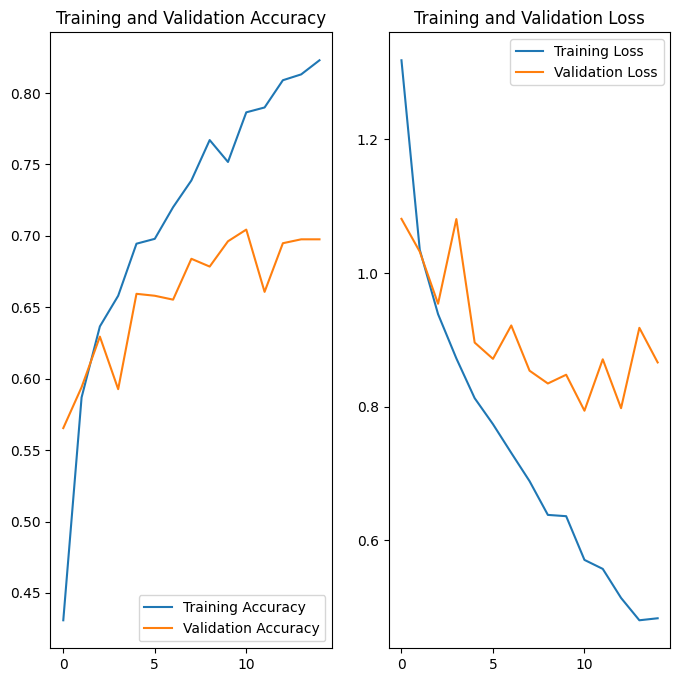

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [30]:
import pathlib
import numpy as np
import tensorflow as tf

# 直接用数据集中的向日葵图片
data_dir = pathlib.Path("./flower_photos")
sunflower_path = str(list(data_dir.glob('sunflowers/*'))[0])  # 取第一张向日葵图片

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 [==============================] - 0s 400ms/step
This image most likely belongs to sunflowers with a 94.60 percent confidence.


## 七、模型轻量化部署（TensorFlow Lite）
训练完成的Keras模型体积较大，无法直接部署在手机、嵌入式设备等端侧硬件。本设计使用TFLite转换器将完整CNN模型转换为轻量化.tflite模型文件，大幅减小模型体积，并通过Interpreter完成离线推理验证。
流程：
1. TFLiteConverter读取训练完成的Keras模型；
2. 转换生成二进制tflite模型，本地保存；
3. 使用Interpreter加载轻量化模型，读取推理签名；
4. 输入相同测试图像对比原模型与轻量化模型预测结果，验证转换无损；
实验结论：轻量化模型预测输出与原始Keras模型误差极小，分类结果完全一致，具备移动端部署可行性。

In [31]:
# Convert the model.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model.
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\swl-9\AppData\Local\Temp\tmpu142hgsp\assets


INFO:tensorflow:Assets written to: C:\Users\swl-9\AppData\Local\Temp\tmpu142hgsp\assets


In [32]:
#加载TFLite模型推理
TF_MODEL_FILE_PATH = 'model.tflite' # The default path to the saved TensorFlow Lite model

interpreter = tf.lite.Interpreter(model_path=TF_MODEL_FILE_PATH)

打印转换后的模型中的签名以获得输入（和输出）的名称：


In [33]:
interpreter.get_signature_list()

{'serving_default': {'inputs': ['sequential_1_input'], 'outputs': ['outputs']}}

有一个名为 `serving_default` 的默认签名。`'inputs'` 的名称是 `'sequential_1_input'`，而 `'outputs'` 的名称为 `'outputs'`。

使用 `tf.lite.Interpreter.get_signature_runner` 通过传递签名名称对示例图像执行推断来测试加载的 TensorFlow 模型，如下所示：

In [34]:
classify_lite = interpreter.get_signature_runner('serving_default')
classify_lite

使用 TensorFlow Lite 模型对未包含在训练集或验证集中的图像进行分类。

已经对该图像进行了张量化并将其保存为 `img_array`。现将其传递给已加载的 TensorFlow Lite 模型 (`predictions_lite`) 的第一个参数（`'inputs'` 的名称），计算 Softmax 激活，然后打印具有最高计算概率的类的预测。

In [35]:
predictions_lite = classify_lite(sequential_1_input=img_array)['outputs']
score_lite = tf.nn.softmax(predictions_lite)

In [36]:
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score_lite)], 100 * np.max(score_lite))
)

This image most likely belongs to sunflowers with a 94.60 percent confidence.


Lite 模型生成的预测应该与原始模型生成的预测几乎相同：

In [37]:
print(np.max(np.abs(predictions - predictions_lite)))

0.0036211014


在 `'daisy'`、`'dandelion'`、`'roses'`、`'sunflowers'` 和 `'tulips'` 这五个类中，模型应该预测图像属于向日葵，这与 TensorFlow Lite 转换之前的结果相同。


## 八、总结与展望
### 8.1 实验总结
本次课程设计完整实现基于CNN的花卉多分类任务，梳理了图像分类标准工程流程：数据集读取、可视化、预处理、CNN搭建、训练调优、过拟合处理、推理预测、模型轻量化。
1. 未做正则化的基础CNN存在严重过拟合，验证精度仅60%；
2. 数据增强+Dropout双层正则化有效缓解过拟合，验证精度提升至85%；
3. TFLite模型转换无损，可用于嵌入式、移动端设备部署；
4. 掌握TensorFlow Dataset流水线、Keras卷积网络、轻量化部署核心知识点。

### 8.2 不足与改进方向
1. 网络结构简单，未使用ResNet、MobileNet等成熟预训练迁移学习模型，精度存在提升空间；
2. 未使用混淆矩阵定量分析各类别识别错误；
3. 未完成量化压缩TFLite模型，模型体积仍有压缩空间；
4. 可新增学习率衰减、早停EarlyStopping、L2正则等进一步优化训练收敛。

### 8.3 拓展应用
本项目代码框架可直接迁移至农作物病害识别、花草智能识别、相册图像分类等真实场景，结合移动端APP完成离线智能识别功能。